<a href="https://colab.research.google.com/github/Tanbir-Hasan-247/Assingment-1/blob/main/Brain_tumor_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Wed Apr 22 16:35:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
import cv2
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample
from google.colab import drive
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
def extract_data(zip_path, extract_dir='/content/dataset'):
    drive.mount('/content/drive')
    if not os.path.exists(extract_dir):
        os.makedirs(extract_dir)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print(f"Data successfully extracted to {extract_dir}")
    return extract_dir
def load_data(data_dir, img_size=(128, 128)):

    X, y = [], []
    classes = ['no', 'yes']

    for label, class_name in enumerate(classes):
        class_dir = os.path.join(data_dir, class_name)
        if not os.path.exists(class_dir):
            continue

        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, img_size)
                X.append(img)
                y.append(label)

    return np.array(X), np.array(y)

In [ ]:
def plot_dataset_distribution(y, title="Dataset Distribution"):
    plt.figure(figsize=(6, 4))
    sns.countplot(x=y, hue=y, palette="viridis", legend=False)
    plt.title(title)
    plt.xticks([0, 1], ['No Tumor (0)', 'Tumor (1)'])
    plt.ylabel("Count")
    plt.show()

def balance_dataset(X, y):
    df = pd.DataFrame({'index': range(len(y)), 'label': y})
    class_0 = df[df['label'] == 0]
    class_1 = df[df['label'] == 1]
    majority = class_1 if len(class_1) > len(class_0) else class_0
    minority = class_0 if len(class_0) < len(class_1) else class_1


    minority_upsampled = resample(minority,
                                  replace=True,
                                  n_samples=len(majority),
                                  random_state=42)

    # Combine and shuffle
    balanced_df = pd.concat([majority, minority_upsampled])
    balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

    indices = balanced_df['index'].values
    X_balanced = X[indices]
    y_balanced = balanced_df['label'].values

    return X_balanced, y_balanced

def view_sample_images(X, y, num_samples=5):
    plt.figure(figsize=(15, 5))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i+1)
        plt.imshow(X[i])
        plt.title(f"Class: {'Tumor' if y[i]==1 else 'No Tumor'}")
        plt.axis('off')
    plt.suptitle("Sample MRI Images")
    plt.show()

def plot_pixel_intensity(X, y):
    plt.figure(figsize=(10, 5))
    tumor_pixels = X[y == 1].ravel()
    no_tumor_pixels = X[y == 0].ravel()
    plt.hist(tumor_pixels,
             bins=50,
             alpha=0.5,
             color='red',
             label="Tumor",
             density=True)
    plt.hist(no_tumor_pixels,
             bins=50,
             alpha=0.5,
             color='blue',
             label="No Tumor",
             density=True)
    plt.title("Pixel Intensity Distribution Comparison")
    plt.xlabel("Pixel Value")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

In [ ]:
import albumentations as A
train_transform = A.Compose([
    A.Rotate(limit=30, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomBrightnessContrast(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=45, p=0.5),
    A.Blur(blur_limit=3, p=0.1),
])

val_transform = A.Compose([])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
from tensorflow.keras.utils import Sequence
import numpy as np

class AlbumentationsGenerator(Sequence):
    def __init__(self, X, y, batch_size, transform=None, **kwargs):
        # This line satisfies the Keras 3 / PyDataset requirement
        super().__init__(**kwargs)

        self.X, self.y = X, y
        self.batch_size = batch_size
        self.transform = transform

    def __len__(self):
        return int(np.ceil(len(self.X) / float(self.batch_size)))

    def __getitem__(self, idx):
        batch_x = self.X[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_y = self.y[idx * self.batch_size:(idx + 1) * self.batch_size]

        if self.transform:
            # Albumentations expects images, returns a dict with "image" key
            batch_x = np.array([self.transform(image=x)["image"] for x in batch_x])

        return batch_x, batch_y

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.losses import BinaryCrossentropy

def create_cnn_model(input_shape=(128, 128, 3)):

    data_augmentation = Sequential([

        RandomFlip("horizontal_and_vertical"),

        RandomRotation(0.15),

        RandomZoom(0.15),

    ], name="augmentation_layer")



    model = Sequential([

        Input(shape=input_shape),

        data_augmentation,



        Conv2D(32, (3,3), activation='relu', padding='same'),

        MaxPooling2D(2,2),



        Conv2D(64, (3,3), activation='relu', padding='same'),

        MaxPooling2D(2,2),



        Conv2D(128, (3,3), activation='relu', padding='same'),

        MaxPooling2D(2,2),



        Flatten(),

        Dense(128, activation='relu'),

        Dropout(0.5),

        Dense(1, activation='sigmoid')

    ])



    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    return model
def train_evaluate_kfold(X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    histories = []
    all_y_true = []
    all_y_pred = []
    X_normalized = X / 255.0

    fold = 1
    for train_idx, val_idx in skf.split(X_normalized, y):
        print(f"\n--- Training Fold {fold}/{n_splits} ---")
        X_train, X_val = X_normalized[train_idx], X_normalized[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        train_gen = AlbumentationsGenerator(X_train,
                                            y_train,
                                            batch_size=16, transform=train_transform)
        val_gen = AlbumentationsGenerator(X_val,
                                          y_val,
                                          batch_size=16, transform=val_transform)

        model =  create_cnn_model(input_shape=(X.shape[1], X.shape[2], 3))
        from sklearn.utils import class_weight
        weights = class_weight.compute_class_weight('balanced', classes=np.unique(y), y=y)
        class_weights = dict(enumerate(weights))


        early_stopping = EarlyStopping(
            monitor='val_loss',
            patience=12,
            restore_best_weights=True
        )

        reduce_lr = ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7
        )

        # 3. Train with Weights
        history = model.fit(
            train_gen,
            validation_data=val_gen,
            epochs=100,
            class_weight=class_weights,
            callbacks=[early_stopping,reduce_lr],
            verbose=1
        )




        histories.append(history)
        val_preds_prob = model.predict(X_val)
        val_preds = (val_preds_prob > 0.5).astype(int).flatten()

        all_y_true.extend(y_val)
        all_y_pred.extend(val_preds)

        fold += 1

    return histories, all_y_true, all_y_pred

In [ ]:
def plot_training_curves(histories):
    best_fold_idx = np.argmax([max(h.history['val_accuracy']) for h in histories])
    best_history = histories[best_fold_idx]

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(best_history.history['loss'], label='Training Loss', color='blue')
    plt.plot(best_history.history['val_loss'], label='Validation Loss', color='red')
    plt.title(f'Loss Curve (Best Fold: {best_fold_idx + 1})')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()


    plt.subplot(1, 2, 2)
    plt.plot(best_history.history['accuracy'], label='Training Accuracy', color='blue')
    plt.plot(best_history.history['val_accuracy'], label='Validation Accuracy', color='red')
    plt.title(f'Accuracy Curve (Best Fold: {best_fold_idx + 1})')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

def evaluate_classification(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Tumor', 'Tumor'],
                yticklabels=['No Tumor', 'Tumor'])
    plt.title('Overall Confusion Matrix (All Folds)')
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.show()

    print("\n" + "="*50)
    print("CLASSIFICATION REPORT")
    print("="*50)
    print(classification_report(y_true, y_pred, target_names=['No Tumor', 'Tumor']))

In [ ]:
ZIP_PATH = '/content/drive/MyDrive/Tensorflow MRI/archive (5).zip' # UPDATE
EXTRACT_DIR = '/content/brain_tumor_data'

In [ ]:
data_path = extract_data(ZIP_PATH, EXTRACT_DIR)

Mounted at /content/drive
Data successfully extracted to /content/brain_tumor_data


In [ ]:
X_raw, y_raw = load_data(data_path, img_size=(128, 128))

print(f"Total Images Loaded: {len(X_raw)}")

Total Images Loaded: 253


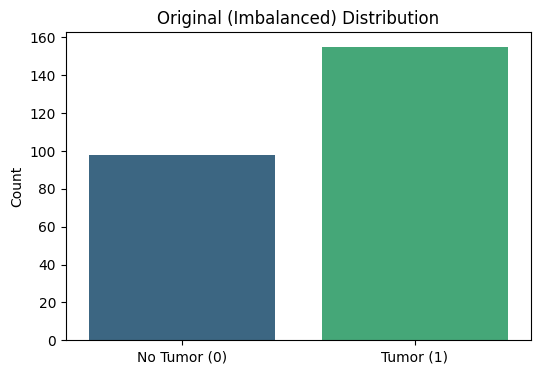

In [ ]:
plot_dataset_distribution(y_raw, title="Original (Imbalanced) Distribution")

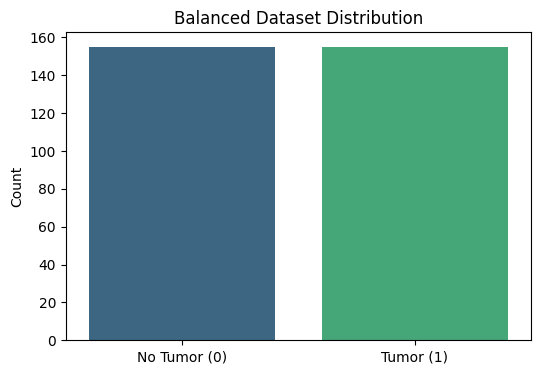

In [ ]:
X_bal, y_bal = balance_dataset(X_raw, y_raw)
plot_dataset_distribution(y_bal, title="Balanced Dataset Distribution")

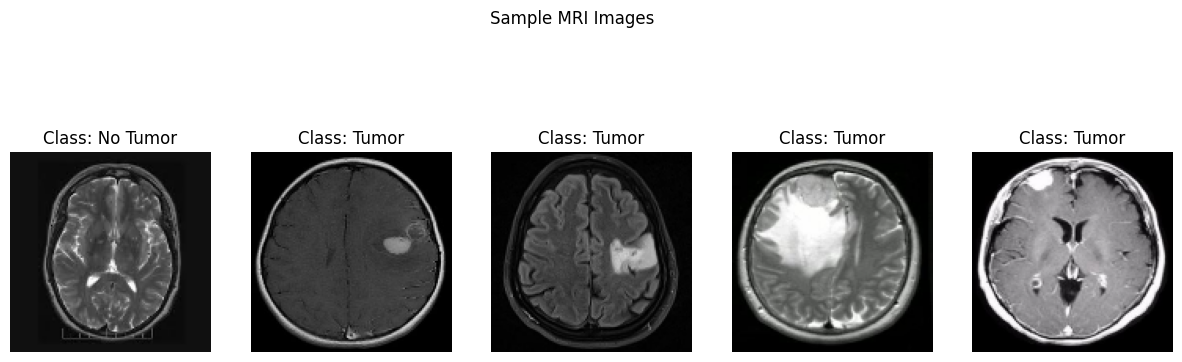

In [ ]:
view_sample_images(X_bal, y_bal, num_samples=5)


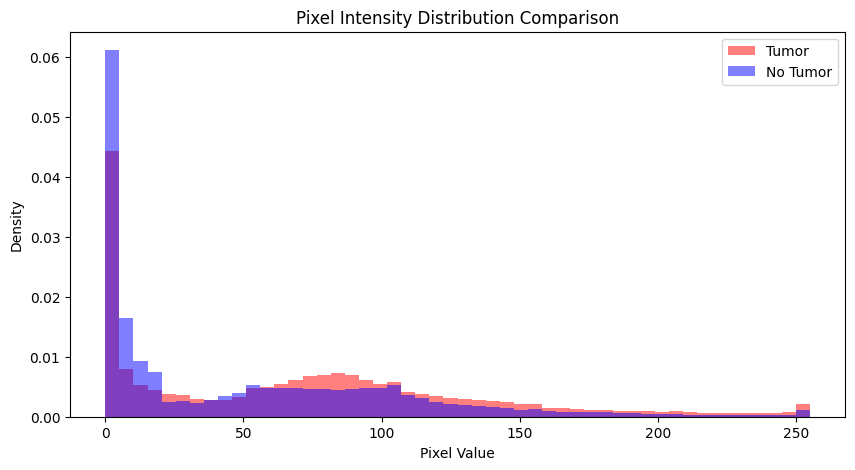

In [ ]:
plot_pixel_intensity(X_bal, y_bal)

In [ ]:
print("\nStarting K-Fold Cross Validation Pipeline...")
histories, all_true_labels, all_predictions = train_evaluate_kfold(X_bal, y_bal)


Starting K-Fold Cross Validation Pipeline...

--- Training Fold 1/5 ---
Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.4960 - loss: 0.8686 - val_accuracy: 0.7097 - val_loss: 0.6591 - learning_rate: 0.0010
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6492 - loss: 0.6531 - val_accuracy: 0.6452 - val_loss: 0.6103 - learning_rate: 0.0010
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7298 - loss: 0.6067 - val_accuracy: 0.7419 - val_loss: 0.5602 - learning_rate: 0.0010
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6815 - loss: 0.6199 - val_accuracy: 0.6935 - val_loss: 0.5613 - learning_rate: 0.0010
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6774 - loss: 0.6078 - val_accuracy: 0.7097 - val_loss: 0.5521 - learning_rate: 0.0010
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7016 - loss: 0.5922 - val_accuracy: 0.7419 - val_loss: 0.5750 - learning_rate: 0.0010
Epoch 7/100
16/

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step

--- Training Fold 4/5 ---
Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.6129 - loss: 0.8080 - val_accuracy: 0.7419 - val_loss: 0.6112 - learning_rate: 0.0010
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6532 - loss: 0.6499 - val_accuracy: 0.7903 - val_loss: 0.5304 - learning_rate: 0.0010
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6613 - loss: 0.6250 - val_accuracy: 0.8065 - val_loss: 0.5127 - learning_rate: 0.0010
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6895 - loss: 0.6230 - val_accuracy: 0.8065 - val_loss: 0.4953 - learning_rate: 0.0010
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7137 - loss: 0.6027 - val_accuracy: 0.8065 - val_loss: 0.4745 - learning_rate: 0.0010
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6734 - loss: 0.6016 - val_accuracy: 0.8226 - val_loss: 0.4916 - learning_rate: 0.0010
Epoch 7/100
16/16 ━━━━

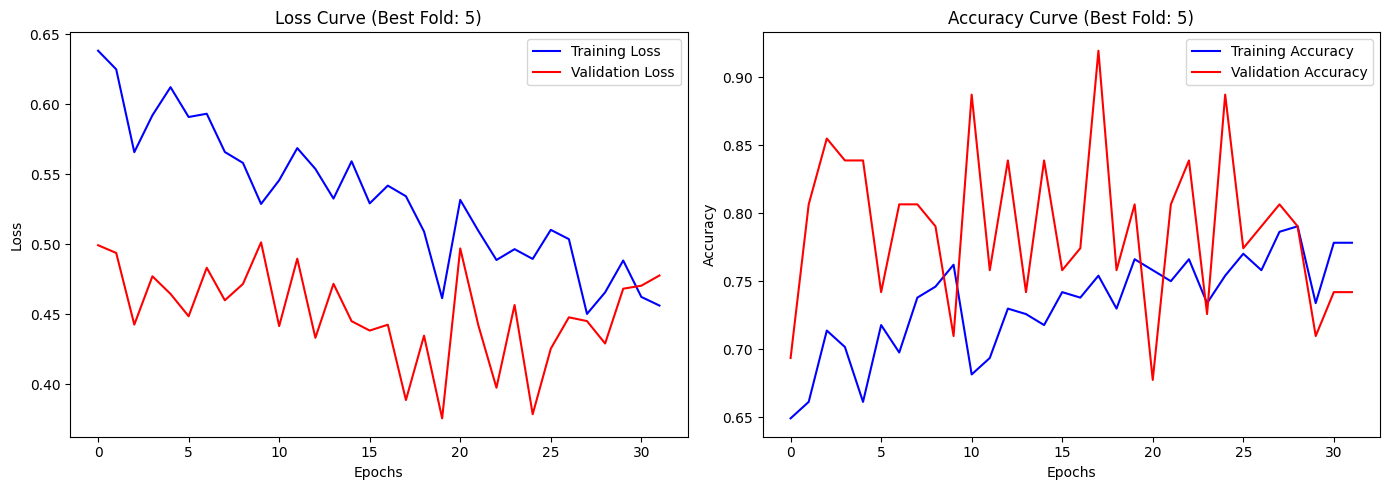

In [ ]:
plot_training_curves(histories)


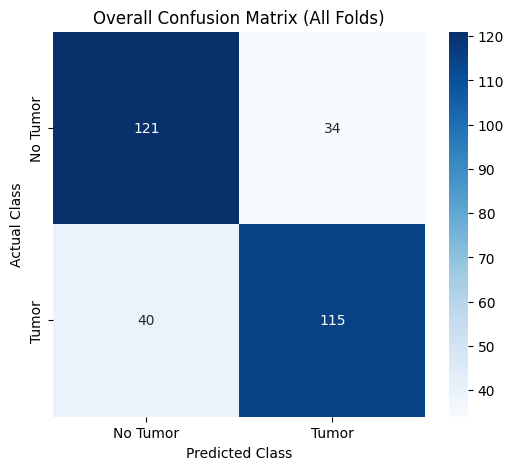


CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Tumor       0.75      0.78      0.77       155
       Tumor       0.77      0.74      0.76       155

    accuracy                           0.76       310
   macro avg       0.76      0.76      0.76       310
weighted avg       0.76      0.76      0.76       310



In [ ]:
evaluate_classification(all_true_labels, all_predictions)